# Fig1

In [1]:
# import shap
import matplotlib.pyplot as plt
# from sklearn.datasets import make_regression
# from sklearn.ensemble import RandomForestRegressor
# shap.initjs()

In [2]:
# X, y = make_regression(n_samples=100, n_features=2, random_state=0)
# model = RandomForestRegressor(random_state=0)
# model.fit(X, y)
# explainer = shap.KernelExplainer(model.predict, X)
# shap_values = explainer.shap_values(X)

In [3]:
# number_of_features = [2, 4, 6, 8, 10, 12]
# run_time = [2, 4, 12, 33, 105, 176]
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
# ax.plot(number_of_features, run_time, marker='o')
# ax.set_xlabel('Number of Features', fontsize=10)
# ax.set_ylabel('Runtime (sec.)', fontsize=10)
# plt.show()

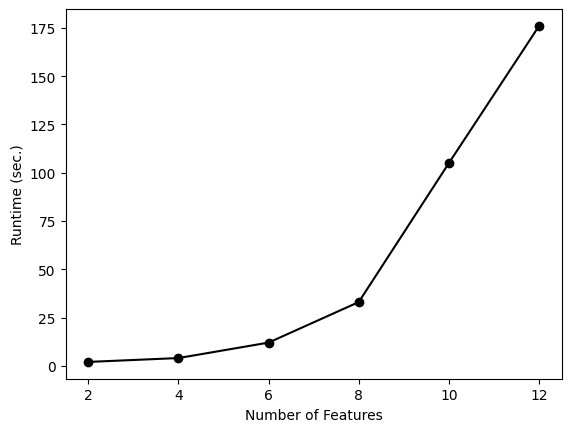

In [4]:
# BW
number_of_features = [2, 4, 6, 8, 10, 12]
run_time = [2, 4, 12, 33, 105, 176]
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(number_of_features, run_time, marker='o', c='black')
ax.set_xlabel('Number of Features', fontsize=10)
ax.set_ylabel('Runtime (sec.)', fontsize=10)
plt.show()
fig.savefig('Fig1.eps', format='eps')

---

# Fig2

In [5]:
from copy import deepcopy
from sklearn.datasets import load_diabetes
from sklearn.inspection import partial_dependence
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [6]:
diabetes = load_diabetes(scaled=False)
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f'Train Set Size: {X_train.shape}')
print(f'Test Set Size: {X_test.shape}')

Train Set Size: (309, 10)
Test Set Size: (133, 10)


In [8]:
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))

0.30925702609395644


In [9]:
ice_values = partial_dependence(model, X_test, [feature_names.index('age')], kind='both')
c_ice_values = deepcopy(ice_values)
c_ice_values['individual'][0] -= c_ice_values['individual'][0][:, 0].reshape(-1, 1)
c_ice_values['average'][0] -= c_ice_values['average'][0][0]

In [10]:
# fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))
# for i in range(len(X_test)):
#     ax[0].plot(ice_values['values'][0], ice_values['individual'][0][i], c='gray', linewidth=0.5)
# ax[0].plot(ice_values['values'][0], ice_values['average'][0], c='red')
# ax[0].set_xlabel('age', fontsize=10)
# ax[0].set_ylabel('partial yhat', fontsize=10)
# for i in range(len(X_test)):
#     ax[1].plot(c_ice_values['values'][0], c_ice_values['individual'][0][i], c='gray', linewidth=0.5)
# ax[1].plot(c_ice_values['values'][0], c_ice_values['average'][0], c='red')
# ax[1].set_xlabel('age', fontsize=10)
# ax[1].set_ylabel('partial yhat (centered)', fontsize=10)
# plt.show()

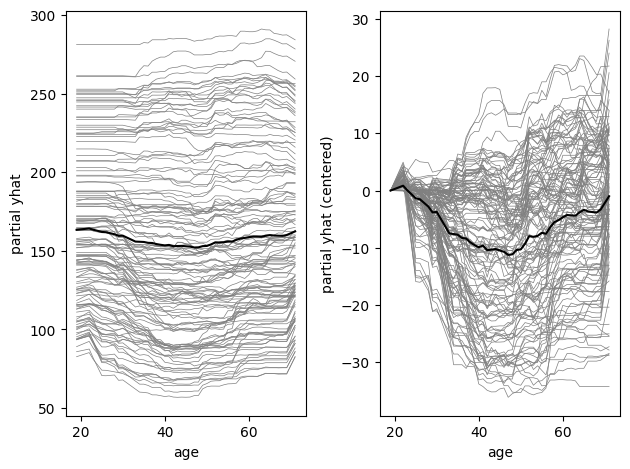

In [14]:
# BW
fig, ax = plt.subplots(1, 2)
for i in range(len(X_test)):
    ax[0].plot(ice_values['values'][0], ice_values['individual'][0][i], c='gray', linewidth=0.5)
ax[0].plot(ice_values['values'][0], ice_values['average'][0], c='black')
ax[0].set_xlabel('age', fontsize=10)
ax[0].set_ylabel('partial yhat', fontsize=10)
for i in range(len(X_test)):
    ax[1].plot(c_ice_values['values'][0], c_ice_values['individual'][0][i], c='gray', linewidth=0.5)
ax[1].plot(c_ice_values['values'][0], c_ice_values['average'][0], c='black')
ax[1].set_xlabel('age', fontsize=10)
ax[1].set_ylabel('partial yhat (centered)', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig2.eps', format='eps')

---

# Fig4 & 5

In [1]:
import IEE
import shap
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(0)
X = np.random.multivariate_normal(mean=[0, 0, 0, 0], cov=np.identity(4), size=1000)
e = np.random.normal(loc=0, scale=0.1, size=1000)
y = X[:, 0] * X[:, 1] * X[:, 2] + e
feature_names = [f'X{i}' for i in range(1, X.shape[1] + 1)]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f'Train Set Size: {X_train.shape}')
print(f'Test Set Size: {X_test.shape}')

Train Set Size: (700, 4)
Test Set Size: (300, 4)


In [4]:
model = SVR()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.76126595269182


In [5]:
explainer = IEE.Explainer(model)
iee_values = explainer(X_test)

In [6]:
kernel_explainer = shap.KernelExplainer(model.predict, shap.sample(X_train, random_state=0))
shap_values = kernel_explainer.shap_values(X_test)

  0%|          | 0/300 [00:00<?, ?it/s]

In [7]:
# fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12.8, 3.4))
# ax[0].barh(feature_names, abs(shap_values).mean(0), color='#1E90FF')
# ax[1].barh(feature_names, iee_values.mean(0), color='orange')
# ax[0].set_xlabel('Kernel SHAP', fontsize=10)
# ax[1].set_xlabel('IEE', fontsize=10)
# fig.tight_layout()
# plt.show()

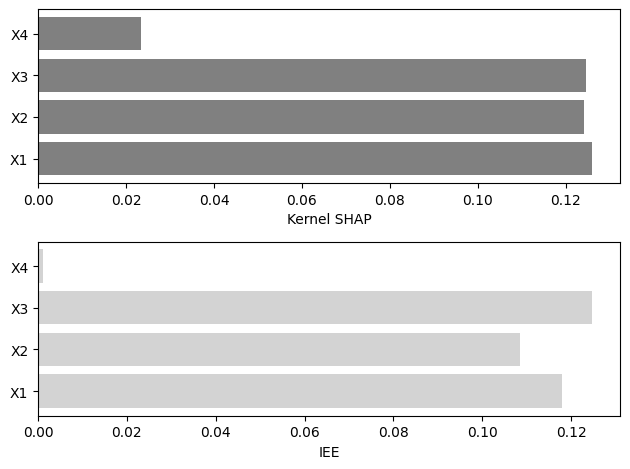

In [9]:
# BW
fig, ax = plt.subplots(2, 1, sharey=True)
ax[0].barh(feature_names, abs(shap_values).mean(0), color='gray')
ax[1].barh(feature_names, iee_values.mean(0), color='lightgray')
ax[0].set_xlabel('Kernel SHAP', fontsize=10)
ax[1].set_xlabel('IEE', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig4.eps', format='eps')

In [24]:
# fig, ax = plt.subplots(3, 3, figsize=(12.8, 4.8 * 2))
# ax[0, 0].barh(feature_names, X_test[4], color='gray')
# ax[0, 1].barh(feature_names, abs(shap_values)[4], color='#1E90FF')
# ax[0, 2].barh(feature_names, iee_values[4], color='orange')
# ax[0, 0].set_xlabel('Feature Values for the 4th Data', fontsize=10)
# ax[0, 1].set_xlabel('Kernel SHAP', fontsize=10)
# ax[0, 2].set_xlabel('IEE', fontsize=10)
# ax[1, 0].barh(feature_names, X_test[22], color='gray')
# ax[1, 1].barh(feature_names, abs(shap_values)[22], color='#1E90FF')
# ax[1, 2].barh(feature_names, iee_values[22], color='orange')
# ax[1, 0].set_xlabel('Feature Values for the 22nd Data', fontsize=10)
# ax[1, 1].set_xlabel('Kernel SHAP', fontsize=10)
# ax[1, 2].set_xlabel('IEE', fontsize=10)
# ax[2, 0].barh(feature_names, X_test[30], color='gray')
# ax[2, 1].barh(feature_names, abs(shap_values)[30], color='#1E90FF')
# ax[2, 2].barh(feature_names, iee_values[30], color='orange')
# ax[2, 0].set_xlabel('Feature Values for the 30th Data', fontsize=10)
# ax[2, 1].set_xlabel('Kernel SHAP', fontsize=10)
# ax[2, 2].set_xlabel('IEE', fontsize=10)
# fig.tight_layout(pad=3)
# plt.show()

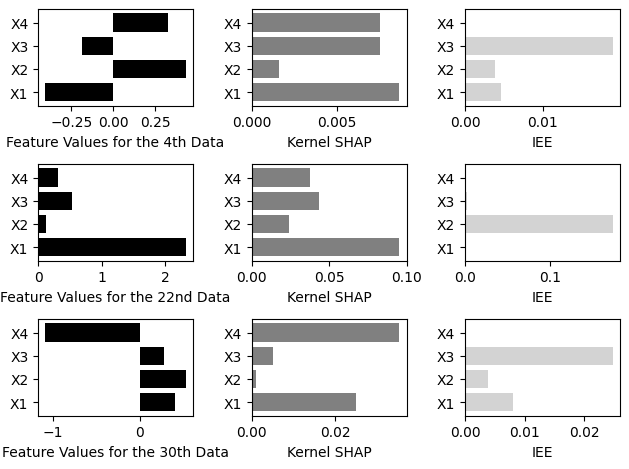

In [26]:
# BW
fig, ax = plt.subplots(3, 3)
ax[0, 0].barh(feature_names, X_test[4], color='black')
ax[0, 1].barh(feature_names, abs(shap_values)[4], color='gray')
ax[0, 2].barh(feature_names, iee_values[4], color='lightgray')
ax[0, 0].set_xlabel('Feature Values for the 4th Data', fontsize=10)
ax[0, 1].set_xlabel('Kernel SHAP', fontsize=10)
ax[0, 2].set_xlabel('IEE', fontsize=10)
ax[1, 0].barh(feature_names, X_test[22], color='black')
ax[1, 1].barh(feature_names, abs(shap_values)[22], color='gray')
ax[1, 2].barh(feature_names, iee_values[22], color='lightgray')
ax[1, 0].set_xlabel('Feature Values for the 22nd Data', fontsize=10)
ax[1, 1].set_xlabel('Kernel SHAP', fontsize=10)
ax[1, 2].set_xlabel('IEE', fontsize=10)
ax[2, 0].barh(feature_names, X_test[30], color='black')
ax[2, 1].barh(feature_names, abs(shap_values)[30], color='gray')
ax[2, 2].barh(feature_names, iee_values[30], color='lightgray')
ax[2, 0].set_xlabel('Feature Values for the 30th Data', fontsize=10)
ax[2, 1].set_xlabel('Kernel SHAP', fontsize=10)
ax[2, 2].set_xlabel('IEE', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig5.eps', format='eps')

---

# Fig 3 & 6 & 9

In [27]:
import IEE
import shap
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [28]:
california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f'Train Set Size: {X_train.shape}')
print(f'Test Set Size: {X_test.shape}')

Train Set Size: (14448, 8)
Test Set Size: (6192, 8)


In [30]:
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.794153372413094


In [31]:
explainer = IEE.Explainer(model)
iee_values = explainer(X_test)

In [32]:
kernel_explainer = shap.KernelExplainer(model.predict, shap.sample(X_train, random_state=0))

In [33]:
# shap_values = kernel_explainer.shap_values(X_test)
with open('shap_values_california_rf.pkl', 'rb') as f:
    shap_values = pickle.load(f)

In [34]:
# fig, ax = plt.subplots(1, 3, sharey=True, figsize=(12.8, 4.8))
# ax[0].barh(feature_names, X_test[33], color='gray')
# ax[1].barh(feature_names, abs(shap_values)[33], color='#1E90FF')
# ax[2].barh(feature_names, iee_values[33], color='orange')
# ax[0].set_xlabel('Feature Values for the 33rd Data', fontsize=10)
# ax[1].set_xlabel('Kernel SHAP', fontsize=10)
# ax[2].set_xlabel('IEE', fontsize=10)
# fig.tight_layout()
# plt.show()

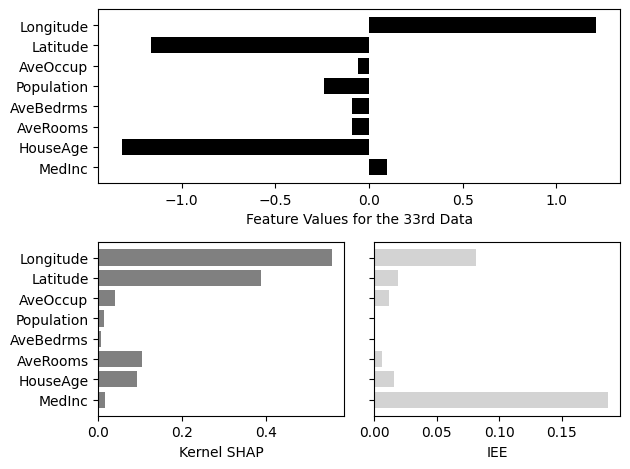

In [50]:
# BW
fig, ax = plt.subplot_mosaic([['feature values', 'feature values'], ['shap', 'iee']], sharey=True)
ax['feature values'].barh(feature_names, X_test[33], color='black')
ax['shap'].barh(feature_names, abs(shap_values)[33], color='gray')
ax['iee'].barh(feature_names, iee_values[33], color='lightgray')
ax['feature values'].set_xlabel('Feature Values for the 33rd Data', fontsize=10)
ax['shap'].set_xlabel('Kernel SHAP', fontsize=10)
ax['iee'].set_xlabel('IEE', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig6.eps', format='eps')

In [51]:
# explainer.ice_plot(iee_values, 33, feature_names=feature_names)

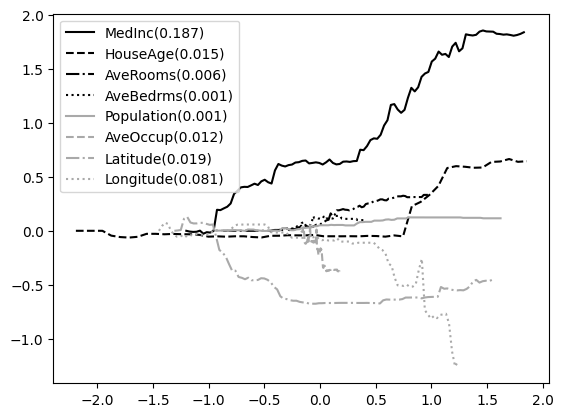

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [52]:
# BW
linestyle = ['-', '--', '-.', ':', '-', '--', '-.', ':']
color = ['black', 'black', 'black', 'black', 'darkgray', 'darkgray', 'darkgray', 'darkgray']
fig, ax = plt.subplots()
for i in range(iee_values.shape[1]):
    label = f'{feature_names[i]}({round(iee_values[33, i], 3)})'
    ax.plot(explainer.ice_values[i]['values'], explainer.ice_values[i]['individual'][0][33], linestyle=linestyle[i], color=color[i], label=label)
ax.legend(fontsize=10)
plt.show()
fig.savefig('Fig3.eps', format='eps')

In [53]:
# fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12.8, 4.8))
# ax[0].barh(feature_names, abs(shap_values).mean(0), color='#1E90FF')
# ax[1].barh(feature_names, iee_values.mean(0), color='orange')
# ax[0].set_xlabel('Kernel SHAP', fontsize=10)
# ax[1].set_xlabel('IEE', fontsize=10)
# fig.tight_layout()
# plt.show()

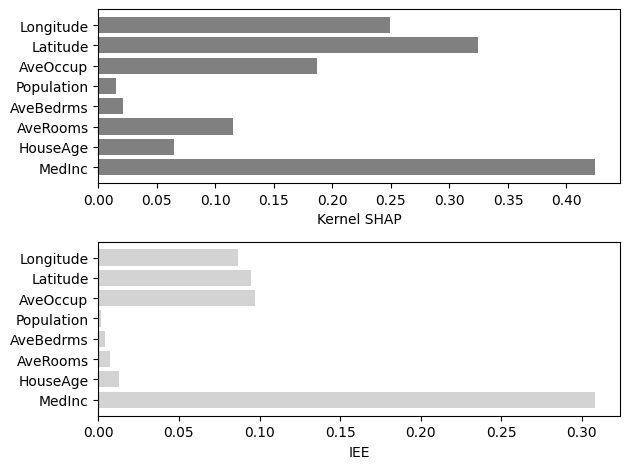

In [55]:
# BW
fig, ax = plt.subplots(2, 1, sharey=True)
ax[0].barh(feature_names, abs(shap_values).mean(0), color='gray')
ax[1].barh(feature_names, iee_values.mean(0), color='lightgray')
ax[0].set_xlabel('Kernel SHAP', fontsize=10)
ax[1].set_xlabel('IEE', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig7.eps', format='eps')

---

# Fig 7 & 8

In [56]:
import IEE
import shap
import pickle
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [57]:
diabetes = load_diabetes(scaled=False)
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f'Train Set Size: {X_train.shape}')
print(f'Test Set Size: {X_test.shape}')

Train Set Size: (309, 10)
Test Set Size: (133, 10)


In [59]:
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.3117978342953317


In [60]:
explainer = IEE.Explainer(model)
iee_values = explainer(X_test)

In [61]:
kernel_explainer = shap.KernelExplainer(model.predict, shap.sample(X_train, random_state=0))

In [62]:
# shap_values = kernel_explainer.shap_values(X_test)
with open('shap_values_diabetes_rf.pkl', 'rb') as f:
    shap_values = pickle.load(f)

In [63]:
# explainer.ice_plot(iee_values, 11, feature_names=feature_names)

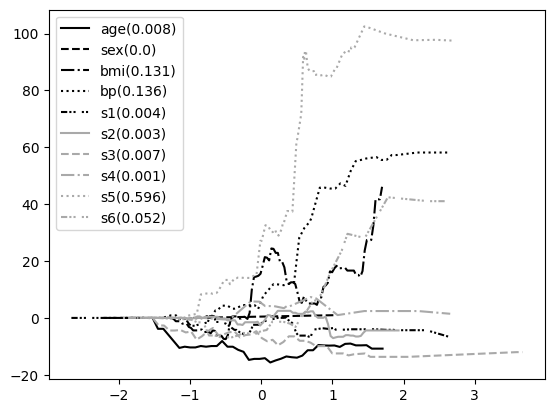

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [64]:
# BW
linestyle = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1)), '-', '--', '-.', ':', (0, (3, 1, 1, 1, 1))]
color = ['black', 'black', 'black', 'black', 'black', 'darkgray', 'darkgray', 'darkgray', 'darkgray', 'darkgray']
fig, ax = plt.subplots()
for i in range(iee_values.shape[1]):
    label = f'{feature_names[i]}({round(iee_values[11, i], 3)})'
    ax.plot(explainer.ice_values[i]['values'], explainer.ice_values[i]['individual'][0][11], linestyle=linestyle[i], color=color[i], label=label)
ax.legend(fontsize=10)
plt.show()
fig.savefig('Fig8.eps', format='eps')

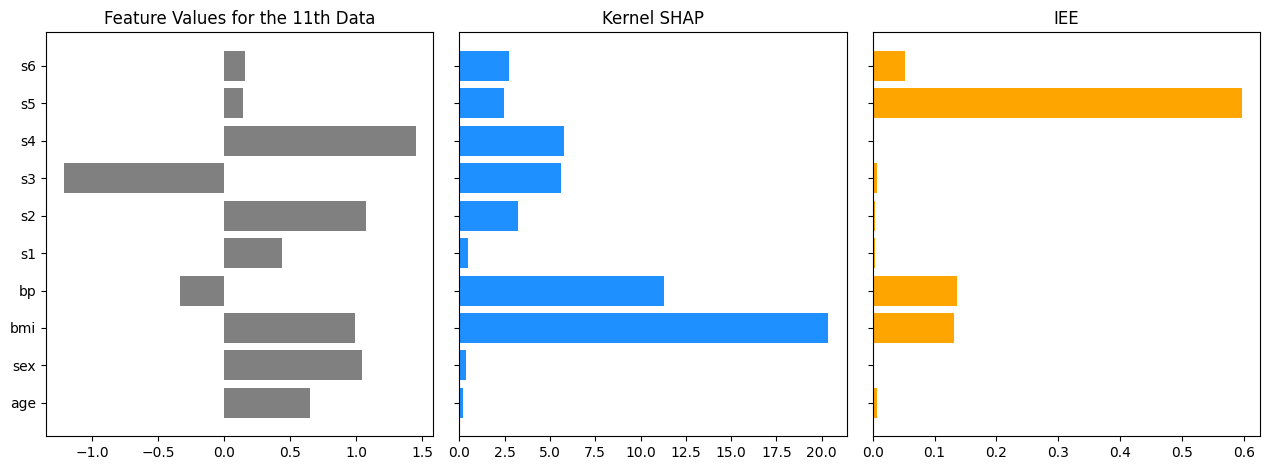

In [67]:
# fig, ax = plt.subplots(1, 3, sharey=True, figsize=(12.8, 4.8))
# ax[0].barh(feature_names, X_test[11], color='gray')
# ax[1].barh(feature_names, abs(shap_values)[11], color='#1E90FF')
# ax[2].barh(feature_names, iee_values[11], color='orange')
# ax[0].set_title('Feature Values for the 11th Data')
# ax[1].set_title('Kernel SHAP')
# ax[2].set_title('IEE')
# fig.tight_layout()
# plt.show()

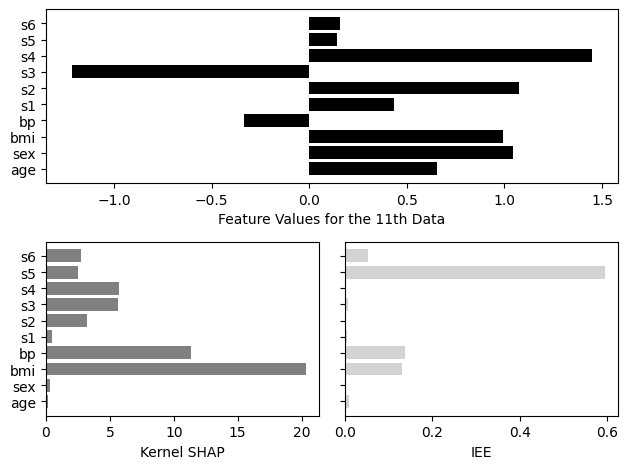

In [68]:
# BW
fig, ax = plt.subplot_mosaic([['feature values', 'feature values'], ['shap', 'iee']], sharey=True)
ax['feature values'].barh(feature_names, X_test[11], color='black')
ax['shap'].barh(feature_names, abs(shap_values)[11], color='gray')
ax['iee'].barh(feature_names, iee_values[11], color='lightgray')
ax['feature values'].set_xlabel('Feature Values for the 11th Data', fontsize=10)
ax['shap'].set_xlabel('Kernel SHAP', fontsize=10)
ax['iee'].set_xlabel('IEE', fontsize=10)
fig.tight_layout()
plt.show()
fig.savefig('Fig9.eps', format='eps')